Notes/ Definitions:
NDCI = Normalized Difference Chlorophyll Index
It's calculated as:
(Band 5 - Band 4) / (Band 5 + Band 4)

Band 4 = red light (665nm) - absorbed heavily by chlorophyll
Band 5 = red-edge light (705nm) - reflected more by algae/phytoplankton

When algae is present, chlorophyll absorbs more red light (B4 drops) and reflects more red-edge light (B5 rises), so the ratio goes up. More algae = higher NDCI.

source: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndci/#:~:text=The%20Normalized%20Difference%20Chlorophyll%20Index%20(NDCI)%20is,in%20inland%20waters%20from%20Sentinel%2D2A%20satellite%20imagery

# Authenticate Google Earth Engine

In [ ]:
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='yale-capstone-hab')

In [ ]:
# Test it's working
print(ee.String('Earth Engine connected successfully!').getInfo())

Earth Engine connected successfully!


# Import Necessities

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Find Pond and create Df from properties

In [ ]:
# used https://livingatlas.arcgis.com/sentinel2explorer to find pond center
# pond = ee.Geometry.Point([-73.60508, 42.10069])
pond = ee.Geometry.Point([-73.60446, 42.09987])

# Load Sentinel-2 surface reflectance, cloud filtered, growing season only
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(pond)
    .filterDate('2017-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .filter(ee.Filter.calendarRange(5, 10, 'month')))

# Calc NDCI using Band 5 (red edge) and Band 4 (red)
def add_ndci(image):
    ndci = image.normalizedDifference(['B5', 'B4']).rename('NDCI')
    return image.addBands(ndci).set('date', image.date().format('YYYY-MM-dd'))

s2_ndci = s2.map(add_ndci)
print('Usable scenes found:', s2_ndci.size().getInfo())

Usable scenes found: 100


In [ ]:
def extract_value(image):
    val = image.select('NDCI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=pond.buffer(50),  # 50m buffer around pond center
        scale=10
    ).get('NDCI')
    return ee.Feature(None, {'date': image.get('date'), 'NDCI': val})

values = s2_ndci.map(extract_value).getInfo()

In [ ]:
# make df
rows = [f['properties'] for f in values['features']]
df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.dropna().sort_values('date')
print(df.head(10))

       NDCI       date
0 -0.022584 2017-06-12
1  0.096102 2017-07-02
2  0.006049 2017-07-30
3  0.041955 2017-08-26
4 -0.098025 2017-10-03
5 -0.161855 2017-10-18
6  0.006439 2018-05-01
7  0.007257 2018-05-11
8  0.029257 2018-05-23
9  0.015838 2018-06-12


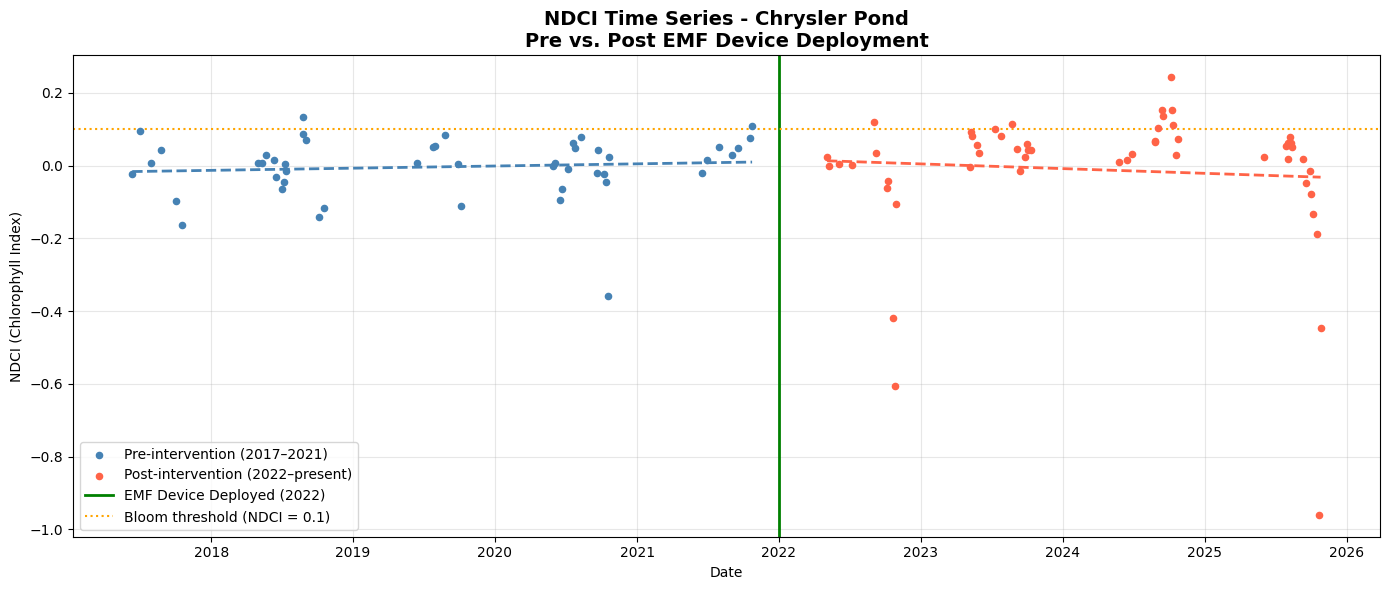

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Split pre and post intervention
pre = df[df['date'] < '2022-01-01']
post = df[df['date'] >= '2022-01-01']

# Plot points
ax.scatter(pre['date'], pre['NDCI'], color='steelblue', s=20, label='Pre-intervention (2017–2021)', zorder=3)
ax.scatter(post['date'], post['NDCI'], color='tomato', s=20, label='Post-intervention (2022–present)', zorder=3)

# Trend lines
for subset, color in [(pre, 'steelblue'), (post, 'tomato')]:
    z = np.polyfit(subset['date'].astype(np.int64), subset['NDCI'], 1)
    p = np.poly1d(z)
    ax.plot(subset['date'], p(subset['date'].astype(np.int64)),
            color=color, linewidth=2, linestyle='--')

# Intervention line
ax.axvline(pd.Timestamp('2022-01-01'), color='green', linewidth=2,
           linestyle='-', label='EMF Device Deployed (2022)')

# Bloom threshold line
ax.axhline(0.1, color='orange', linewidth=1.5,
           linestyle=':', label='Bloom threshold (NDCI = 0.1)')

# Labels
ax.set_title('NDCI Time Series - Chrysler Pond\nPre vs. Post EMF Device Deployment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NDCI (Chlorophyll Index)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ndci_timeseries.png', dpi=150)
plt.show()

In [ ]:
print("=== PRE-INTERVENTION (2017-2021) ===")
print(f"Mean NDCI:        {pre['NDCI'].mean():.4f}")
print(f"Peak NDCI:        {pre['NDCI'].max():.4f}")
print(f"Scenes above 0.1: {(pre['NDCI'] > 0.1).sum()} of {len(pre)}")

print("\n=== POST-INTERVENTION (2022-present) ===")
print(f"Mean NDCI:        {post['NDCI'].mean():.4f}")
print(f"Peak NDCI:        {post['NDCI'].max():.4f}")
print(f"Scenes above 0.1: {(post['NDCI'] > 0.1).sum()} of {len(post)}")

print("\n=== CHANGE ===")
print(f"Mean NDCI change: {post['NDCI'].mean() - pre['NDCI'].mean():.4f}")

=== PRE-INTERVENTION (2017-2021) ===
Mean NDCI:        -0.0031
Peak NDCI:        0.1350
Scenes above 0.1: 2 of 47

=== POST-INTERVENTION (2022-present) ===
Mean NDCI:        -0.0112
Peak NDCI:        0.2433
Scenes above 0.1: 9 of 53

=== CHANGE ===
Mean NDCI change: -0.0081


In [ ]:
# Remove implausible values
# NDCI below -0.3 over open water = can be assumed cloud shadow
df_clean = df[df['NDCI'] > -0.3].copy()

print(f"Removed {len(df) - len(df_clean)} outlier scenes")
print(f"Remaining scenes: {len(df_clean)}")

# Re-split
pre_c = df_clean[df_clean['date'] < '2022-01-01']
post_c = df_clean[df_clean['date'] >= '2022-01-01']

print("\n=== PRE-INTERVENTION (cleaned) ===")
print(f"Mean NDCI:        {pre_c['NDCI'].mean():.4f}")
print(f"Peak NDCI:        {pre_c['NDCI'].max():.4f}")
print(f"Scenes above 0.1: {(pre_c['NDCI'] > 0.1).sum()} of {len(pre_c)}")

print("\n=== POST-INTERVENTION (cleaned) ===")
print(f"Mean NDCI:        {post_c['NDCI'].mean():.4f}")
print(f"Peak NDCI:        {post_c['NDCI'].max():.4f}")
print(f"Scenes above 0.1: {(post_c['NDCI'] > 0.1).sum()} of {len(post_c)}")

print("\n=== CHANGE ===")
print(f"Mean NDCI change: {post_c['NDCI'].mean() - pre_c['NDCI'].mean():.4f}")

Removed 5 outlier scenes
Remaining scenes: 95

=== PRE-INTERVENTION (cleaned) ===
Mean NDCI:        0.0046
Peak NDCI:        0.1350
Scenes above 0.1: 2 of 46

=== POST-INTERVENTION (cleaned) ===
Mean NDCI:        0.0374
Peak NDCI:        0.2433
Scenes above 0.1: 9 of 49

=== CHANGE ===
Mean NDCI change: 0.0328


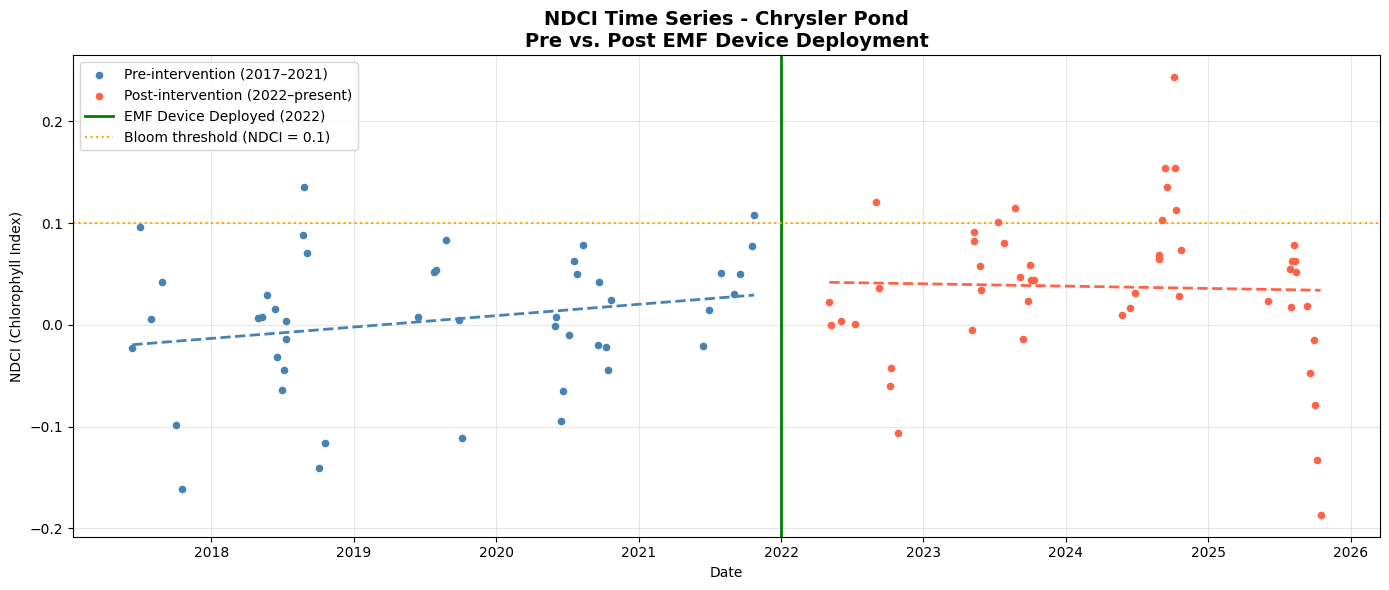

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Split pre and post intervention
pre = df_clean[df_clean['date'] < '2022-01-01']
post = df_clean[df_clean['date'] >= '2022-01-01']

# Plot points
ax.scatter(pre['date'], pre['NDCI'], color='steelblue', s=20, label='Pre-intervention (2017–2021)', zorder=3)
ax.scatter(post['date'], post['NDCI'], color='tomato', s=20, label='Post-intervention (2022–present)', zorder=3)

# Trend lines
for subset, color in [(pre, 'steelblue'), (post, 'tomato')]:
    z = np.polyfit(subset['date'].astype(np.int64), subset['NDCI'], 1)
    p = np.poly1d(z)
    ax.plot(subset['date'], p(subset['date'].astype(np.int64)),
            color=color, linewidth=2, linestyle='--')

# Intervention line
ax.axvline(pd.Timestamp('2022-01-01'), color='green', linewidth=2,
           linestyle='-', label='EMF Device Deployed (2022)')

# Bloom threshold line
ax.axhline(0.1, color='orange', linewidth=1.5,
           linestyle=':', label='Bloom threshold (NDCI = 0.1)')

# Labels
ax.set_title('NDCI Time Series - Chrysler Pond\nPre vs. Post EMF Device Deployment',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('NDCI (Chlorophyll Index)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ndci_timeseries.png', dpi=150)
plt.show()

In [ ]:
# Log which scenes were removed and why
removed = df[df['NDCI'] < -0.3][['date', 'NDCI']]
print("\nRemoved scenes:")
print(removed.to_string())


Removed scenes:
         date      NDCI
38 2020-10-17 -0.359489
55 2022-10-22 -0.418179
56 2022-10-27 -0.605841
98 2025-10-21 -0.960367
99 2025-10-26 -0.445187


Note for transparency: all removed scenes are late October dates, which is when we would start to see/expect ice, frost, or low-sun shadow artifacts.

In [ ]:
# Break down by season to see WHEN blooms are occurring
df_clean['year'] = df_clean['date'].dt.year
df_clean['month'] = df_clean['date'].dt.month

# Mean NDCI per year (growing season)
annual = df_clean.groupby('year')['NDCI'].agg(['mean', 'max',
         lambda x: (x > 0.1).sum()]).reset_index()
annual.columns = ['year', 'mean_ndci', 'peak_ndci', 'bloom_scenes']
print(annual.to_string())

   year  mean_ndci  peak_ndci  bloom_scenes
0  2017  -0.023060   0.096102             0
1  2018  -0.003956   0.134981             1
2  2019   0.015210   0.083568             0
3  2020   0.000536   0.078662             0
4  2021   0.044197   0.107951             1
5  2022  -0.002902   0.120219             1
6  2023   0.054240   0.114705             2
7  2024   0.091894   0.243255             6
8  2025  -0.007158   0.078040             0


Highlights:
2022 & 2025 had the lowest mean_ndci, both post intervention
2023 & 2024 had the highest mean_ndci, both post intervention

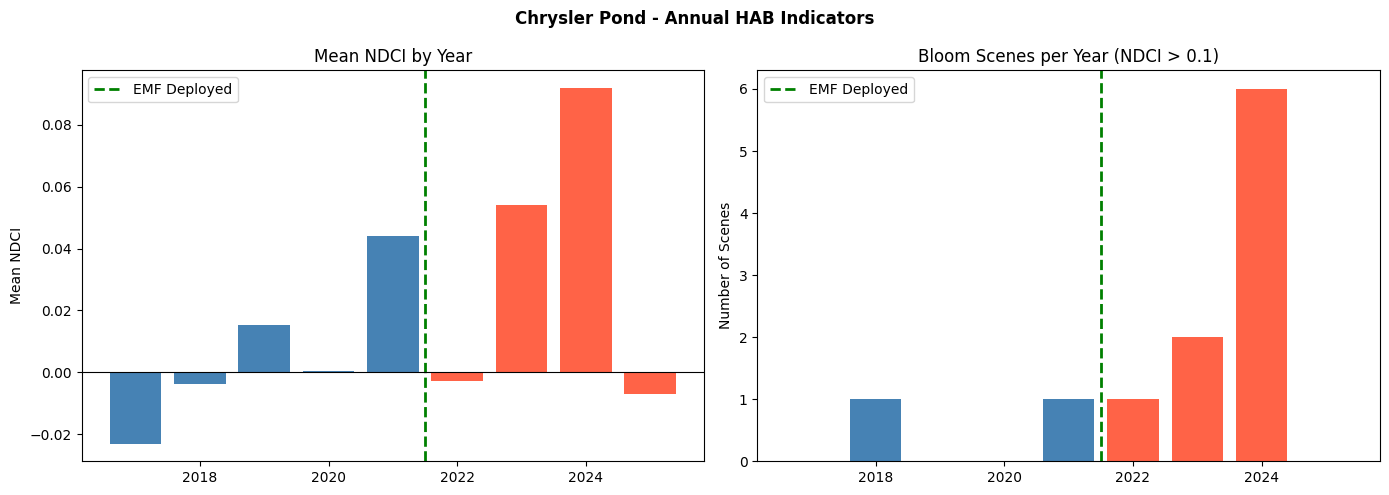

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

years = annual['year']
colors = ['steelblue' if y < 2022 else 'tomato' for y in years]

# Plot 1 - mean NDCI per year
axes[0].bar(years, annual['mean_ndci'], color=colors)
axes[0].axvline(2021.5, color='green', linewidth=2, linestyle='--', label='EMF Deployed')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Mean NDCI by Year')
axes[0].set_ylabel('Mean NDCI')
axes[0].legend()

# Plot 2 - bloom scenes per year
axes[1].bar(years, annual['bloom_scenes'], color=colors)
axes[1].axvline(2021.5, color='green', linewidth=2, linestyle='--', label='EMF Deployed')
axes[1].set_title('Bloom Scenes per Year (NDCI > 0.1)')
axes[1].set_ylabel('Number of Scenes')
axes[1].legend()

plt.suptitle('Chrysler Pond - Annual HAB Indicators', fontweight='bold')
plt.tight_layout()
plt.savefig('annual_breakdown.png', dpi=150)
plt.show()

#Did Weatehr play a part in 2024?

In [ ]:
!pip install openmeteo-requests requests-cache retry-requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.3/707.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.7 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
import requests

In [ ]:

def get_summer_weather(year):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 42.10,
        "longitude": -73.60,
        "start_date": f"{year}-05-01",
        "end_date": f"{year}-10-01",
        "daily": ["temperature_2m_mean", "precipitation_sum"],
        "timezone": "America/New_York"
    }
    r = requests.get(url, params=params).json()
    df = pd.DataFrame(r['daily'])
    return {
        'year': year,
        'mean_temp_c': round(df['temperature_2m_mean'].mean(), 1),
        'total_precip_mm': round(df['precipitation_sum'].sum(), 0)
    }

weather_rows = [get_summer_weather(y) for y in range(2017, 2026)]
weather_df = pd.DataFrame(weather_rows)
print(weather_df.to_string())

   year  mean_temp_c  total_precip_mm
0  2017         17.6            500.0
1  2018         19.2            646.0
2  2019         18.2            518.0
3  2020         18.9            412.0
4  2021         18.6            744.0
5  2022         19.3            451.0
6  2023         18.0            769.0
7  2024         19.5            453.0
8  2025         18.2            637.0


In [ ]:
# Merge weather and NDCI data
summary = annual.merge(weather_df, on='year')
summary['period'] = summary['year'].apply(
    lambda x: 'Pre-intervention' if x < 2022 else 'Post-intervention')

print(summary[['year', 'mean_ndci', 'bloom_scenes',
               'mean_temp_c', 'total_precip_mm', 'period']].to_string())

# Correlation between temperature and bloom scenes
from scipy import stats
corr, pval = stats.pearsonr(summary['mean_temp_c'], summary['bloom_scenes'])
print(f"\nTemp vs Bloom correlation: r={corr:.3f}, p={pval:.3f}")

corr2, pval2 = stats.pearsonr(summary['total_precip_mm'], summary['bloom_scenes'])
print(f"Precip vs Bloom correlation: r={corr2:.3f}, p={pval2:.3f}")

   year  mean_ndci  bloom_scenes  mean_temp_c  total_precip_mm             period
0  2017  -0.023060             0         17.6            500.0   Pre-intervention
1  2018  -0.003956             1         19.2            646.0   Pre-intervention
2  2019   0.015210             0         18.2            518.0   Pre-intervention
3  2020   0.000536             0         18.9            412.0   Pre-intervention
4  2021   0.044197             1         18.6            744.0   Pre-intervention
5  2022  -0.002902             1         19.3            451.0  Post-intervention
6  2023   0.054240             2         18.0            769.0  Post-intervention
7  2024   0.091894             6         19.5            453.0  Post-intervention
8  2025  -0.007158             0         18.2            637.0  Post-intervention

Temp vs Bloom correlation: r=0.534, p=0.138
Precip vs Bloom correlation: r=-0.085, p=0.828


Not statistically significant.

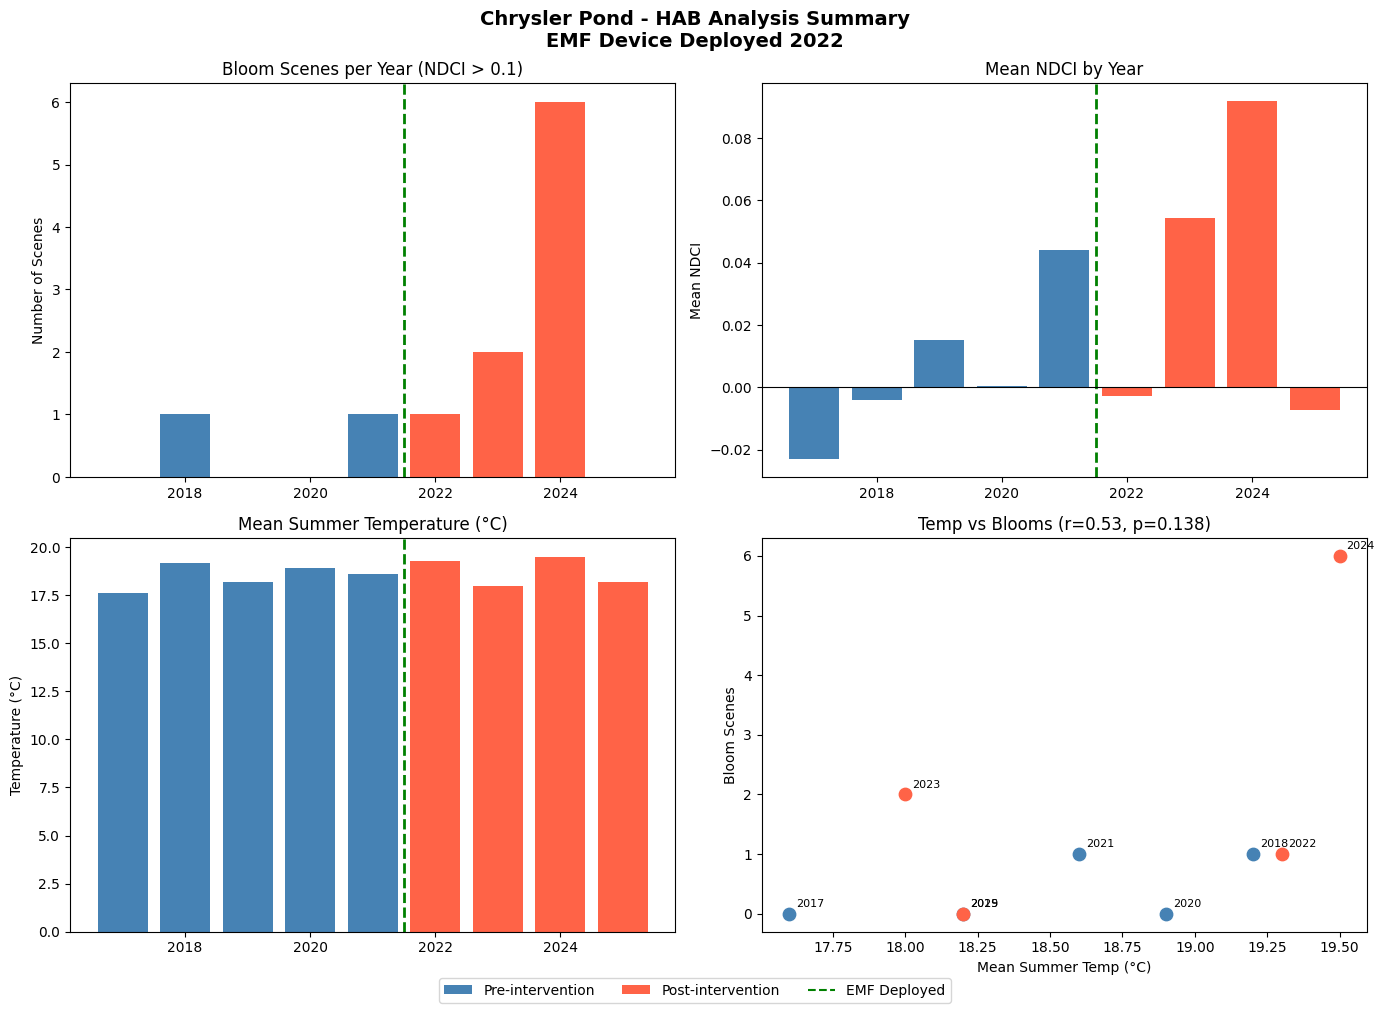

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Chrysler Pond - HAB Analysis Summary\nEMF Device Deployed 2022',
             fontweight='bold', fontsize=14)

colors = ['steelblue' if y < 2022 else 'tomato' for y in summary['year']]

# Plot 1 - Bloom scenes per year
axes[0,0].bar(summary['year'], summary['bloom_scenes'], color=colors)
axes[0,0].axvline(2021.5, color='green', linewidth=2, linestyle='--')
axes[0,0].set_title('Bloom Scenes per Year (NDCI > 0.1)')
axes[0,0].set_ylabel('Number of Scenes')

# Plot 2 - Mean NDCI per year
axes[0,1].bar(summary['year'], summary['mean_ndci'], color=colors)
axes[0,1].axvline(2021.5, color='green', linewidth=2, linestyle='--')
axes[0,1].axhline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Mean NDCI by Year')
axes[0,1].set_ylabel('Mean NDCI')

# Plot 3 - Temperature over time
axes[1,0].bar(summary['year'], summary['mean_temp_c'], color=colors)
axes[1,0].axvline(2021.5, color='green', linewidth=2, linestyle='--')
axes[1,0].set_title('Mean Summer Temperature (°C)')
axes[1,0].set_ylabel('Temperature (°C)')

# Plot 4 - Scatter temp vs blooms
for _, row in summary.iterrows():
    c = 'steelblue' if row['year'] < 2022 else 'tomato'
    axes[1,1].scatter(row['mean_temp_c'], row['bloom_scenes'],
                      color=c, s=80, zorder=3)
    axes[1,1].annotate(str(int(row['year'])),
                       (row['mean_temp_c'], row['bloom_scenes']),
                       textcoords="offset points", xytext=(5,5), fontsize=8)

axes[1,1].set_title(f'Temp vs Blooms (r={0.534:.2f}, p=0.138)')
axes[1,1].set_xlabel('Mean Summer Temp (°C)')
axes[1,1].set_ylabel('Bloom Scenes')

# Shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Pre-intervention'),
                   Patch(facecolor='tomato', label='Post-intervention'),
                   plt.Line2D([0], [0], color='green', linestyle='--',
                              label='EMF Deployed')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('hab_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()